In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv(r'./final_df.csv')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 64104 entries, 0 to 64103
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      64104 non-null  int64  
 1   order_number    64104 non-null  str    
 2   order_date      64104 non-null  str    
 3   customer_name   64104 non-null  str    
 4   channel         64104 non-null  str    
 5   product_name    64104 non-null  str    
 6   order_quantity  64104 non-null  int64  
 7   unit_price      64104 non-null  float64
 8   revenue         64104 non-null  float64
 9   cost            64104 non-null  float64
 10  state_code      64104 non-null  str    
 11  county          64104 non-null  str    
 12  state_name      64104 non-null  str    
 13  region name     64104 non-null  str    
 14  lat             64104 non-null  float64
 15  budget          39 non-null     float64
dtypes: float64(5), int64(2), str(9)
memory usage: 13.3 MB


In [3]:
df.columns

Index(['Unnamed: 0', 'order_number', 'order_date', 'customer_name', 'channel',
       'product_name', 'order_quantity', 'unit_price', 'revenue', 'cost',
       'state_code', 'county', 'state_name', 'region name', 'lat', 'budget'],
      dtype='str')

# Sales & Cost Columns — Quick Reference

These four columns describe the relationship between **how many products were sold, the selling price, the cost of the product, and the total cost**.

| Column           | Meaning                                     | Example | Formula                      |
| ---------------- | ------------------------------------------- | ------: | ---------------------------- |
| `order_quantity` | Number of units/products sold in the order  |    `10` | —                            |
| `unit_price`     | Selling price of **1 unit** to the customer |  `₹100` | —                            |
| `unit_cost`      | Business cost of **1 unit**                 |   `₹60` | —                            |
| `total_cost`     | Total cost for all units in the order       |  `₹600` | `order_quantity × unit_cost` |

## Example

Suppose a customer orders **10 units**:

```text
order_quantity = 10
unit_price     = ₹100
unit_cost      = ₹60
```

### Revenue

Revenue is the total amount received from the customer:

```text
Revenue = order_quantity × unit_price

        = 10 × ₹100

        = ₹1,000
```

### Total Cost

Total cost is the total amount the business spends on those 10 units:

```text
Total Cost = order_quantity × unit_cost

           = 10 × ₹60

           = ₹600
```

### Profit

Profit is what remains after subtracting the total cost from revenue:

```text
Profit = Revenue − Total Cost

       = ₹1,000 − ₹600

       = ₹400
```

## Easy way to remember

Think of it like this:

```text
                 1 UNIT
                   │
        ┌──────────┴──────────┐
        │                     │
   Unit Price              Unit Cost
   ₹100                    ₹60
   │                         │
   │                         │
   └────── × Quantity ───────┘
              │
              ▼
        ┌─────────────┐
        │             │
      Revenue      Total Cost
       ₹1,000         ₹600
        │               │
        └───────┬───────┘
                ▼
             Profit
              ₹400
```

### Pandas formulas

```python
# Revenue
df['revenue'] = df['order_quantity'] * df['unit_price']

# Total Cost
df['total_cost'] = df['order_quantity'] * df['unit_cost']

# Profit
df['profit'] = df['revenue'] - df['total_cost']
```

> **Important:** If your dataset has a column named `cost` instead of `unit_cost`, first check whether `cost` represents the **cost per unit** or the **total cost for the order**. Don't automatically multiply it by `order_quantity`.


In [4]:
df.iloc[0:6, 6:10]

,order_quantity,unit_price,revenue,cost
0,6,2499.1,14994.6,1824.343
1,11,2351.7,25868.7,1269.918
2,6,978.2,5869.2,684.740
3,7,2338.3,16368.1,1028.852
4,8,2291.4,18331.2,1260.270
5,11,5219.3,57412.3,4332.019


In [5]:

df = df.rename(columns={
    'cost': 'unit_cost'
})

# Total Cost
df['total_cost'] = df['order_quantity'] * df['unit_cost']

# Profit
df['profit'] = df['revenue'] - df['total_cost']

In [6]:
# Profit Margin Percentage%
df['profit_margit_%'] = (df['profit']/df['revenue'])*100

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 64104 entries, 0 to 64103
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       64104 non-null  int64  
 1   order_number     64104 non-null  str    
 2   order_date       64104 non-null  str    
 3   customer_name    64104 non-null  str    
 4   channel          64104 non-null  str    
 5   product_name     64104 non-null  str    
 6   order_quantity   64104 non-null  int64  
 7   unit_price       64104 non-null  float64
 8   revenue          64104 non-null  float64
 9   unit_cost        64104 non-null  float64
 10  state_code       64104 non-null  str    
 11  county           64104 non-null  str    
 12  state_name       64104 non-null  str    
 13  region name      64104 non-null  str    
 14  lat              64104 non-null  float64
 15  budget           39 non-null     float64
 16  total_cost       64104 non-null  float64
 17  profit           64104 

In [8]:
df.iloc[0:6, [1,5,6,7,8,9,16,17,18]]

,order_number,product_name,order_quantity,unit_price,revenue,unit_cost,total_cost,profit,profit_margit_%
0,SO - 000225,Product 27,6,2499.1,14994.6,1824.343,10946.058,4048.542,27.0
1,SO - 0003378,Product 20,11,2351.7,25868.7,1269.918,13969.098,11899.602,46.0
2,SO - 0005126,Product 26,6,978.2,5869.2,684.740,4108.440,1760.760,30.0
3,SO - 0005614,Product 7,7,2338.3,16368.1,1028.852,7201.964,9166.136,56.0
4,SO - 0005781,Product 8,8,2291.4,18331.2,1260.270,10082.160,8249.040,45.0
5,SO - 0010394,Product 23,11,5219.3,57412.3,4332.019,47652.209,9760.091,17.0


### EDA

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 64104 entries, 0 to 64103
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       64104 non-null  int64  
 1   order_number     64104 non-null  str    
 2   order_date       64104 non-null  str    
 3   customer_name    64104 non-null  str    
 4   channel          64104 non-null  str    
 5   product_name     64104 non-null  str    
 6   order_quantity   64104 non-null  int64  
 7   unit_price       64104 non-null  float64
 8   revenue          64104 non-null  float64
 9   unit_cost        64104 non-null  float64
 10  state_code       64104 non-null  str    
 11  county           64104 non-null  str    
 12  state_name       64104 non-null  str    
 13  region name      64104 non-null  str    
 14  lat              64104 non-null  float64
 15  budget           39 non-null     float64
 16  total_cost       64104 non-null  float64
 17  profit           64104 

#### Line chart of Monthly Sales

In [19]:
df['order_date'] = pd.to_datetime(df['order_date'])
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 64104 entries, 0 to 64103
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Unnamed: 0       64104 non-null  int64         
 1   order_number     64104 non-null  str           
 2   order_date       64104 non-null  datetime64[us]
 3   customer_name    64104 non-null  str           
 4   channel          64104 non-null  str           
 5   product_name     64104 non-null  str           
 6   order_quantity   64104 non-null  int64         
 7   unit_price       64104 non-null  float64       
 8   revenue          64104 non-null  float64       
 9   unit_cost        64104 non-null  float64       
 10  state_code       64104 non-null  str           
 11  county           64104 non-null  str           
 12  state_name       64104 non-null  str           
 13  region name      64104 non-null  str           
 14  lat              64104 non-null  float64       
 

In [20]:
df['order_date'].dt.to_period("M")

0        2014-01
1        2014-01
2        2014-01
3        2014-01
4        2014-01
          ...   
64099    2018-02
64100    2018-02
64101    2018-02
64102    2018-02
64103    2018-02
Name: order_date, Length: 64104, dtype: period[M]

In [21]:
df['order_month'] = df['order_date'].dt.to_period("M")

In [26]:
monthly_sales = df.groupby('order_month')['revenue'].sum()
monthly_sales

order_month
2014-01    25020272.3
2014-02    23882719.5
2014-03    23709035.4
2014-04    24853382.0
2014-05    25662165.8
2014-06    23818794.8
2014-07    23491988.9
2014-08    25408229.1
2014-09    25459497.5
2014-10    24259835.7
2014-11    26268221.0
2014-12    25686587.3
2015-01    25525914.6
2015-02    23027431.0
2015-03    24360945.4
2015-04    23744217.1
2015-05    24995904.4
2015-06    24528391.8
2015-07    24808203.9
2015-08    26155634.2
2015-09    24662586.1
2015-10    25466197.5
2015-11    25573136.2
2015-12    25562148.2
2016-01    24862829.0
2016-02    23151247.0
2016-03    26420512.0
2016-04    23179165.9
2016-05    25265324.8
2016-06    24804170.5
2016-07    24814997.7
2016-08    25082099.9
2016-09    24551560.4
2016-10    25896129.8
2016-11    25078997.8
2016-12    24976635.2
2017-01    24017201.9
2017-02    21241586.2
2017-03    26123159.3
2017-04    23447990.0
2017-05    26348721.5
2017-06    23761335.6
2017-07    24070011.3
2017-08    25301062.6
2017-09    24758657.

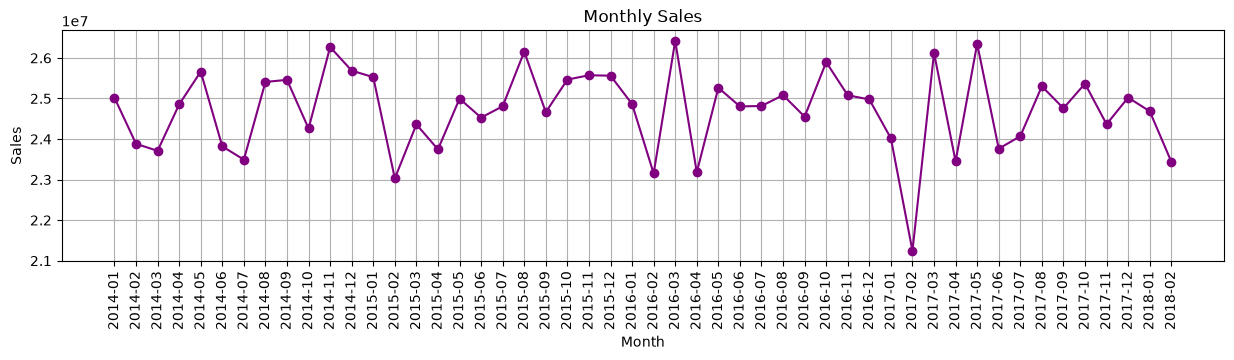

In [50]:
import matplotlib.pyplot as plt
plt.figure(figsize=(15, 3))
plt.plot(
    monthly_sales.index.astype(str), 
    monthly_sales.values,
    color='purple', 
    marker="o"
)
plt.title("Monthly Sales")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=90)
plt.grid(True)

plt.show()

In [48]:
monthly_sales[monthly_sales.min() == monthly_sales]

order_month
2017-02    21241586.2
Freq: M, Name: revenue, dtype: float64

In [49]:
monthly_sales[monthly_sales.max() == monthly_sales]

order_month
2016-03    26420512.0
Freq: M, Name: revenue, dtype: float64

#### Line chart of Overall Monthly Sales

In [51]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 64104 entries, 0 to 64103
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Unnamed: 0       64104 non-null  int64         
 1   order_number     64104 non-null  str           
 2   order_date       64104 non-null  datetime64[us]
 3   customer_name    64104 non-null  str           
 4   channel          64104 non-null  str           
 5   product_name     64104 non-null  str           
 6   order_quantity   64104 non-null  int64         
 7   unit_price       64104 non-null  float64       
 8   revenue          64104 non-null  float64       
 9   unit_cost        64104 non-null  float64       
 10  state_code       64104 non-null  str           
 11  county           64104 non-null  str           
 12  state_name       64104 non-null  str           
 13  region name      64104 non-null  str           
 14  lat              64104 non-null  float64       
 

In [58]:
df.iloc[:,2].dt.month_name()

0         January
1         January
2         January
3         January
4         January
           ...   
64099    February
64100    February
64101    February
64102    February
64103    February
Name: order_date, Length: 64104, dtype: str

In [59]:
df['month_name'] = df.iloc[:,2].dt.month_name()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 64104 entries, 0 to 64103
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Unnamed: 0       64104 non-null  int64         
 1   order_number     64104 non-null  str           
 2   order_date       64104 non-null  datetime64[us]
 3   customer_name    64104 non-null  str           
 4   channel          64104 non-null  str           
 5   product_name     64104 non-null  str           
 6   order_quantity   64104 non-null  int64         
 7   unit_price       64104 non-null  float64       
 8   revenue          64104 non-null  float64       
 9   unit_cost        64104 non-null  float64       
 10  state_code       64104 non-null  str           
 11  county           64104 non-null  str           
 12  state_name       64104 non-null  str           
 13  region name      64104 non-null  str           
 14  lat              64104 non-null  float64       
 

In [63]:
month_sort = [
    'January', 'February', 'March', 'April',
    'May', 'June', 'July', 'August',
    'September', 'October', 'November', 'December'
]
overall_monthly_sales = df\
    .groupby('month_name')['revenue']\
    .sum()\
    .reindex(month_sort)
overall_monthly_sales

month_name
January      124111403.0
February     114747751.0
March        100613652.1
April         95224755.0
May          102272116.5
June          96912692.7
July          97185201.8
August       101947025.8
September     99432301.4
October      100988872.2
November     101285199.8
December     101247927.7
Name: revenue, dtype: float64

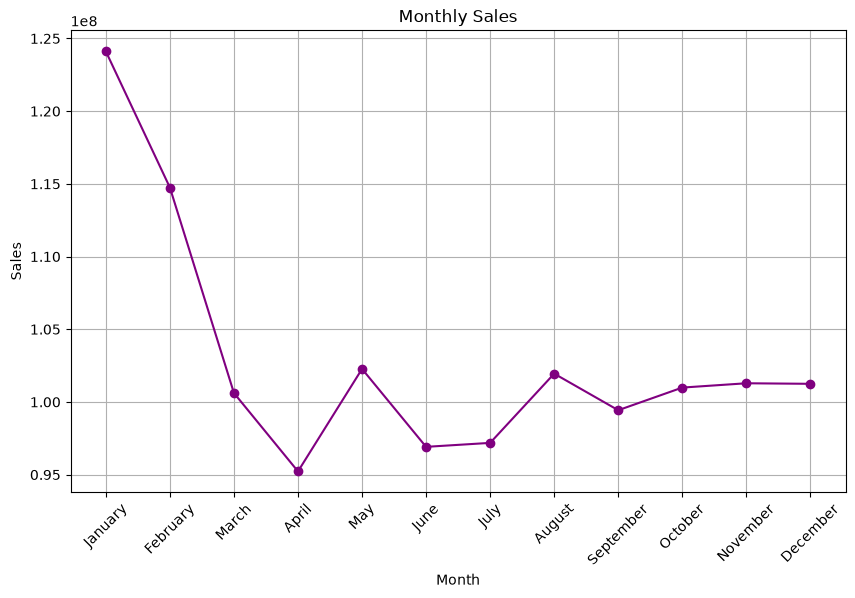

In [64]:

plt.figure(figsize=(10, 6))
plt.plot(
    overall_monthly_sales.index.astype(str), 
    overall_monthly_sales.values,
    color='purple', 
    marker="o"
)
plt.title("Monthly Sales")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.grid(True)

plt.show()